In [1]:
#!pip install mediapipe
!pip uninstall -y onnxruntime
!pip install onnxruntime-gpu
!pip install insightface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.2/283.2 MB 6.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 8.3 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.0/322.0 kB 15.6 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp311-cp311-linux_x86_64.whl size=1060430 sha256=ef14c866a5e03d56a3bef270e1f280147d21c49075d0961794448d9b3f296e0e
  Stored in directory: /root/.cache/pip/wheels/27/d8/22/f52d858d16cd06e7b2e6aad34a1777dcfaf000be833bbf8146
Successfully built insightface
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully 

In [2]:
pip install torch transformers mediapipe librosa opencv-python ffmpeg-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 50.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━

In [3]:
#!pip install timm

**Config.py**

In [4]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import random
from pathlib import Path

if torch.cuda.is_available():
    torch.cuda.init()
    torch.cuda.set_device(0)
    torch.cuda.empty_cache()
    print(f"GPU initialized: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU available, using CPU")

class Config:
    def __init__(self):
        try:
            self.DATASET_PATH = Path("/kaggle/input/dataset2/FakeAVCeleb_v1.2")
            self.METADATA_FILE = self.DATASET_PATH / "meta_data.csv"
            self.PROCESSED_DATA_PATH = Path("/kaggle/working/processed_data")
            self.FEATURE_CACHE_PATH = self.PROCESSED_DATA_PATH / "features"
            self.MODEL_SAVE_PATH = Path("/kaggle/working/models")
            
            self.AUDIO_SAMPLE_RATE = 16000
            self.AUDIO_DURATION = 4
            self.MFCC_FEATURES = 20
            self.N_FFT = 1024
            self.HOP_LENGTH = 256
            
            self.NUM_EPOCHS = 40
            self.LEARNING_RATE = 2e-5
            self.WEIGHT_DECAY = 2e-4
            self.PATIENCE = 10
            self.BATCH_SIZE = 8
            self.NUM_WORKERS = 0
            self.DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            
            self.USE_AUDIO_FEATURES = True
            self.USE_SPECTRAL_FEATURES = True
            
            self.set_seed(42)
            self._setup_dirs()
            
            print(f"Config initialized: Dataset path={self.DATASET_PATH}, Device={self.DEVICE}")
            print(f"Metadata file exists: {self.METADATA_FILE.exists()}")
            
        except Exception as e:
            print(f"Error in Config initialization: {e}")
            raise
    
    def _setup_dirs(self):
        self.PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
        self.FEATURE_CACHE_PATH.mkdir(parents=True, exist_ok=True)
        self.MODEL_SAVE_PATH.mkdir(parents=True, exist_ok=True)
        print(f"Directories created: {self.PROCESSED_DATA_PATH}, {self.FEATURE_CACHE_PATH}, {self.MODEL_SAVE_PATH}")
    
    def set_seed(self, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        print(f"Random seed set to {seed} with deterministic behavior")

config = Config()
print("Config execution completed")

GPU initialized: Tesla T4
Random seed set to 42 with deterministic behavior
Directories created: /kaggle/working/processed_data, /kaggle/working/processed_data/features, /kaggle/working/models
Config initialized: Dataset path=/kaggle/input/dataset2/FakeAVCeleb_v1.2, Device=cuda
Metadata file exists: True
Config execution completed


**feature_extractor.py**


In [5]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import torch
import librosa
import subprocess
import random
import uuid
import pickle
from pathlib import Path

print("Starting FeatureExtractor initialization...")

class FeatureExtractor:
    def __init__(self, config):
        try:
            self.config = config
            print("FeatureExtractor initialized successfully")
        except Exception as e:
            print(f"Error initializing FeatureExtractor: {e}")
            raise

    def augment_audio(self, y, sr):
        try:
            if random.random() > 0.3:
                steps = random.uniform(-6, 6)
                y = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=steps)
            if random.random() > 0.3:
                rate = random.uniform(0.7, 1.3)
                y = librosa.effects.time_stretch(y=y, rate=rate)
            if random.random() > 0.5:
                noise = np.random.normal(0, 0.005, y.shape)
                y = y + noise
            return y
        except Exception as e:
            print(f"Error in augment_audio: {e}")
            return y

    def extract_audio_features(self, video_path):
        cache_path = self.config.FEATURE_CACHE_PATH / f"{video_path.name}_audio.pkl"
        if cache_path.exists():
            try:
                with open(cache_path, 'rb') as f:
                    return pickle.load(f)
            except Exception as e:
                print(f"Error loading audio cache {cache_path}: {e}")

        try:
            audio_path = self._extract_audio(video_path)
            if audio_path is None:
                print(f"No audio extracted from {video_path}")
                return None
            try:
                y, sr = librosa.load(audio_path, sr=self.config.AUDIO_SAMPLE_RATE)
            except Exception as e:
                print(f"Error loading audio {audio_path}: {e}")
                os.remove(audio_path)
                return None
            os.remove(audio_path)

            y = self.augment_audio(y, sr)

            mfcc = librosa.feature.mfcc(
                y=y, sr=sr,
                n_mfcc=self.config.MFCC_FEATURES,
                n_fft=self.config.N_FFT,
                hop_length=self.config.HOP_LENGTH
            )
            features = {'mfcc': mfcc}
            if self.config.USE_SPECTRAL_FEATURES:
                try:
                    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6)
                    spectral_flatness = librosa.feature.spectral_flatness(y=y)
                    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=self.config.N_FFT, hop_length=self.config.HOP_LENGTH)
                    features.update({
                        'spectral_contrast': spectral_contrast,
                        'spectral_flatness': spectral_flatness,
                        'chroma': chroma
                    })
                except Exception as e:
                    print(f"Error computing spectral features for {video_path}: {e}")
            try:
                with open(cache_path, 'wb') as f:
                    pickle.dump(features, f)
            except Exception as e:
                print(f"Error saving audio cache {cache_path}: {e}")
            return features
        except Exception as e:
            print(f"Error in extract_audio_features for {video_path}: {e}")
            if 'audio_path' in locals() and os.path.exists(audio_path):
                os.remove(audio_path)
            return None

    def _extract_audio(self, video_path):
        try:
            audio_path = str(self.config.PROCESSED_DATA_PATH / f"temp_{os.getpid()}_{uuid.uuid4()}.wav")
            command = [
                "ffmpeg", "-y", "-i", str(video_path), "-vn",
                "-acodec", "pcm_s16le", "-ar", str(self.config.AUDIO_SAMPLE_RATE),
                "-ac", "1", "-threads", "1", audio_path
            ]
            result = subprocess.run(
                command,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.PIPE,
                text=True,
                timeout=10
            )
            if result.returncode != 0:
                print(f"ffmpeg error for {video_path}: {result.stderr}")
                return None
            return audio_path
        except Exception as e:
            print(f"Error in _extract_audio for {video_path}: {e}")
            return None

print("FeatureExtractor execution completed")

Starting FeatureExtractor initialization...
FeatureExtractor execution completed


**model.py**

In [6]:
import torch
import torch.nn as nn

class AudioClassifier(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.audio_encoder = nn.Sequential(
            nn.Conv1d(config.MFCC_FEATURES, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.LayerNorm(128)
        )
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=128,
                nhead=2,
                dim_feedforward=512,
                dropout=0.3
            ),
            num_layers=1
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.7),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.7),
            nn.Linear(32, 1)
        )
        print("AudioClassifier initialized")

    def forward(self, audio_feat):
        audio = self.audio_encoder(audio_feat.permute(0, 2, 1))
        audio = audio.unsqueeze(1)  # Add sequence dimension for transformer
        audio = self.transformer(audio)
        audio = audio.mean(dim=1)  # Aggregate transformer output
        return self.classifier(audio)

print("Model module loaded")

Model module loaded


**focal_loss.py**

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Starting FocalLoss definition...")

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.3, gamma=2.5, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        if self.reduction == 'mean':
            return F_loss.mean()
        elif self.reduction == 'sum':
            return F_loss.sum()
        return F_loss

print("FocalLoss execution completed")

Starting FocalLoss definition...
FocalLoss execution completed


**dataset.py**

In [8]:
import numpy as np
import torch
from torch.utils.data import Dataset
import pandas as pd
from pathlib import Path

print("Starting DeepfakeDataset definition...")

class DeepfakeDataset(Dataset):
    def __init__(self, metadata, config, feature_extractor, mode='train'):
        self.config = config
        self.feature_extractor = feature_extractor
        self.mode = mode
        
        self.metadata = metadata[metadata['split'] == mode].reset_index(drop=True)
        self.metadata['label'] = self.metadata['category'].apply(lambda x: 0 if x == 'A' else 1)
        
        self.cache = {}
        self.valid_samples = 0
        self.error_log = []
        if len(self.metadata) == 0:
            print(f"Warning: Empty dataset for {mode} mode")
        else:
            print(f"Dataset for {mode} mode: {len(self.metadata)} samples")
            print(f"Class distribution:\n{self.metadata['label'].value_counts()}")
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        if idx in self.cache:
            return self.cache[idx]
            
        row = self.metadata.iloc[idx]
        
        category_map = {
            'A': 'RealVideo-RealAudio',
            'B': 'RealVideo-FakeAudio',
            'C': 'FakeVideo-RealAudio',
            'D': 'FakeVideo-FakeAudio'
        }
        root_dir = category_map.get(row['category'], 'FakeVideo-FakeAudio')
        race = row.get('race', 'Unknown')
        gender = row.get('gender', 'men').lower()
        source_id = row.get('source', row.get('target1', 'id00000'))
        
        dir_path = self.config.DATASET_PATH / root_dir / race / gender / source_id
        
        video_path = self.config.DATASET_PATH / row['path']
        if video_path.suffix == '.mp4' and video_path.exists():
            print(f"Direct path found: {video_path}")
        else:
            video_files = list(dir_path.glob("*.mp4"))
            if not video_files:
                error_msg = f"No .mp4 files found in {dir_path}"
                print(error_msg)
                self.error_log.append((idx, error_msg))
                return self._get_empty_item()
            video_path = video_files[0]
        
        if not video_path.exists():
            error_msg = f"File not found: {video_path}"
            print(error_msg)
            self.error_log.append((idx, error_msg))
            return self._get_empty_item()
            
        label = row['label']
        
        try:
            audio_features = self.feature_extractor.extract_audio_features(video_path)
            if audio_features is None:
                error_msg = f"Failed to extract audio features for {video_path}"
                print(error_msg)
                self.error_log.append((idx, error_msg))
                return self._get_empty_item()
            
            mfcc = audio_features['mfcc']
            if np.isnan(mfcc).any():
                mfcc = np.nan_to_num(mfcc)
            std_val = mfcc.std(axis=1, keepdims=True)
            if not np.all(std_val == 0):
                mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (std_val + 1e-8)
            audio_feat = self._pad_or_truncate(mfcc.T, 50)
            
            result = {
                'audio': torch.FloatTensor(audio_feat),
                'label': torch.FloatTensor([label]),
                'is_valid': torch.FloatTensor([1])
            }
            
            self.valid_samples += 1
            if self.mode != 'train':
                self.cache[idx] = result
            return result
            
        except Exception as e:
            error_msg = f"Error processing item {idx} for {video_path}: {str(e)}"
            self.error_log.append((idx, error_msg))
            return self._get_empty_item()
    
    def _get_empty_item(self):
        return {
            'audio': torch.zeros(50, self.config.MFCC_FEATURES),
            'label': torch.FloatTensor([0]),
            'is_valid': torch.FloatTensor([0])
        }
    
    @staticmethod
    def _pad_or_truncate(array, target_length):
        if array.shape[0] > target_length:
            return array[:target_length]
        elif array.shape[0] < target_length:
            pad_width = [(0, target_length - array.shape[0])] + [(0, 0)] * (len(array.shape) - 1)
            return np.pad(array, pad_width, mode='constant')
        return array

def collate_fn(batch):
    batch = [item for item in batch if item.get('is_valid', torch.FloatTensor([0])).item() == 1]
    if not batch:
        print("Warning: Empty batch after filtering")
        return {
            'audio': torch.empty(0),
            'label': torch.empty(0),
            'is_valid': torch.empty(0)
        }
    return {
        'audio': torch.stack([item['audio'] for item in batch]),
        'label': torch.stack([item['label'] for item in batch]),
        'is_valid': torch.stack([item['is_valid'] for item in batch])
    }

print("DeepfakeDataset execution completed")

Starting DeepfakeDataset definition...
DeepfakeDataset execution completed


**trainer.py**

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import roc_curve
from tqdm import tqdm
import numpy as np

print("Starting EfficientTrainer definition...")

class EfficientTrainer:
    def __init__(self, config):
        self.config = config
        self.feature_extractor = FeatureExtractor(config)
        self.model = AudioClassifier(config).to(config.DEVICE)
        self.scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer,
            T_max=config.NUM_EPOCHS
        )
        self.criterion = FocalLoss(alpha=0.3, gamma=2.5)
        self.best_score = 0
        self.early_stop_counter = 0
        print("EfficientTrainer initialized")
    
    def train(self, metadata):
        train_dataset = DeepfakeDataset(metadata, self.config, self.feature_extractor, 'train')
        val_dataset = DeepfakeDataset(metadata, self.config, self.feature_extractor, 'val')
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=True,
            num_workers=self.config.NUM_WORKERS,
            pin_memory=True,
            collate_fn=collate_fn
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=False,
            num_workers=self.config.NUM_WORKERS,
            pin_memory=True,
            collate_fn=collate_fn
        )
        
        print(f"Training samples: {train_dataset.valid_samples}/{len(train_dataset)} valid")
        print(f"Validation samples: {val_dataset.valid_samples}/{len(val_dataset)} valid")
        if train_dataset.error_log:
            print(f"Train dataset errors (first 5):")
            for i, (idx, err) in enumerate(train_dataset.error_log[:5]):
                print(f"Error {i+1}: Item {idx}: {err}")
        
        for epoch in range(self.config.NUM_EPOCHS):
            self.model.train()
            train_loss = 0
            train_preds, train_labels = [], []
            valid_batches = 0
            
            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
            for batch in pbar:
                if batch is None:
                    print("Skipping empty batch")
                    continue
                    
                audio = batch['audio'].to(self.config.DEVICE, non_blocking=True)
                labels = batch['label'].to(self.config.DEVICE, non_blocking=True)
                
                self.optimizer.zero_grad(set_to_none=True)
                
                try:
                    with torch.cuda.amp.autocast():
                        outputs = self.model(audio)
                        loss = self.criterion(outputs, labels)
                    
                    self.scaler.scale(loss).backward()
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                    
                    train_loss += loss.item()
                    valid_batches += 1
                    train_preds.extend(torch.sigmoid(outputs).squeeze().detach().cpu().numpy())
                    train_labels.extend(labels.squeeze().detach().cpu().numpy())
                    
                    pbar.set_postfix({'loss': f"{loss.item():.4f}"})
                    
                except RuntimeError as e:
                    if "out of memory" in str(e):
                        print("WARNING: Out of memory, skipping batch")
                        torch.cuda.empty_cache()
                    else:
                        print(f"Error during training: {e}")
                    continue
                finally:
                    del audio, labels, outputs
                    torch.cuda.empty_cache()
            
            self.scheduler.step()
            val_loss, val_metrics = self.evaluate(val_loader)
            train_loss = train_loss / max(1, valid_batches)
            
            print(f"\nEpoch {epoch+1}/{self.config.NUM_EPOCHS}:")
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print(f"Val AUC: {val_metrics['auc']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1']:.4f}")
            print(f"Confusion Matrix:\n{val_metrics['confusion_matrix']}")
            print(f"Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f}")
            
            if val_metrics['auc'] > self.best_score:
                self.best_score = val_metrics['auc']
                self.early_stop_counter = 0
                self._save_model()
            else:
                self.early_stop_counter += 1
                if self.early_stop_counter >= self.config.PATIENCE:
                    print(f"Early stopping after {epoch+1} epochs")
                    break
    
    def evaluate(self, dataloader):
        self.model.eval()
        val_loss = 0
        preds, labels = [], []
        valid_batches = 0
        
        with torch.no_grad():
            for batch in dataloader:
                if batch is None:
                    print("Skipping empty batch in evaluation")
                    continue
                    
                audio = batch['audio'].to(self.config.DEVICE, non_blocking=True)
                labels_batch = batch['label'].to(self.config.DEVICE, non_blocking=True)
                
                try:
                    with torch.cuda.amp.autocast():
                        outputs = self.model(audio)
                        loss = self.criterion(outputs, labels_batch)
                    
                    val_loss += loss.item()
                    valid_batches += 1
                    preds.extend(torch.sigmoid(outputs).squeeze().detach().cpu().numpy())
                    labels.extend(labels_batch.squeeze().detach().cpu().numpy())
                except Exception as e:
                    print(f"Error during evaluation: {e}")
                    continue
                finally:
                    del audio, labels_batch, outputs
                    torch.cuda.empty_cache()
        
        if valid_batches == 0 or len(preds) == 0:
            print("No valid batches in evaluation")
            return 0, {
                'auc': 0, 'accuracy': 0, 'f1': 0,
                'confusion_matrix': np.zeros((2,2)),
                'precision': 0, 'recall': 0,
                'roc_curve': ([0], [0], [0])
            }
            
        val_loss /= valid_batches
        metrics = self._calculate_metrics(preds, labels)
        return val_loss, metrics
    
    def _calculate_metrics(self, preds, labels):
        preds = np.array(preds)
        labels = np.array(labels)
        binary_preds = (preds > 0.5).astype(int)
        
        try:
            auc = roc_auc_score(labels, preds)
            fpr, tpr, thresholds = roc_curve(labels, preds)
        except Exception:
            auc = 0.5
            fpr, tpr, thresholds = [0], [0], [0]
            
        precision, recall, f1, _ = precision_recall_fscore_support(labels, binary_preds, average='binary', zero_division=0)
        
        return {
            'auc': auc,
            'accuracy': accuracy_score(labels, binary_preds),
            'f1': f1,
            'confusion_matrix': confusion_matrix(labels, binary_preds),
            'precision': precision,
            'recall': recall,
            'roc_curve': (fpr, tpr, thresholds)
        }
    
    def _save_model(self):
        save_path = self.config.MODEL_SAVE_PATH / "best_model.pth"
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_score': self.best_score,
            'config': {k: v for k, v in vars(self.config).items() if not callable(v) and not k.startswith('__')}
        }, save_path)
        print(f"Model saved with best AUC: {self.best_score:.4f}")

print("EfficientTrainer execution completed")

Starting EfficientTrainer definition...
EfficientTrainer execution completed


**Enhanced_main.py** 

Starting main execution...
Random seed set to 42 with deterministic behavior
Directories created: /kaggle/working/processed_data, /kaggle/working/processed_data/features, /kaggle/working/models
Config initialized: Dataset path=/kaggle/input/dataset2/FakeAVCeleb_v1.2, Device=cuda
Metadata file exists: True
Available columns in meta_data.csv: ['source', 'target1', 'target2', 'method', 'category', 'type', 'race', 'gender', 'path']
First 5 rows of metadata:
         path category     race gender   source
0  00109.mp4        A  African    men  id00076
1  00010.mp4        A  African    men  id00166
2  00118.mp4        A  African    men  id00173
3  00118.mp4        A  African    men  id00366
4  00052.mp4        A  African    men  id00391

Validating first 5 paths:
Directory /kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00076: 1 .mp4 files found
Directory /kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00166: 1 .mp4 files found
Directory /k

AudioClassifier Epoch 1: 100%|██████████| 2157/2157 [05:22<00:00,  6.68it/s, loss=0.0101]


[AudioClassifier] Epoch 1/40, Loss: 0.0172, Accuracy: 0.9028
Dataset for val mode: 2157 samples
Class distribution:
label
1    2102
0      55
Name: count, dtype: int64


AudioClassifier Evaluating: 100%|██████████| 270/270 [00:08<00:00, 32.94it/s]


[AudioClassifier] Val Loss: 0.0068 | Val AUC: 0.7636 | Val Acc: 0.9745 | Val F1: 0.9871
AudioClassifier saved with best AUC: 0.7636


...

[AudioClassifier] Val Loss: 0.0069 | Val AUC: 0.9492 | Val Acc: 0.9940 | Val F1: 0.9969


AudioClassifier Epoch 39: 100%|██████████| 2157/2157 [00:41<00:00, 51.83it/s, loss=0.0000]


[AudioClassifier] Epoch 39/40, Loss: 0.0014, Accuracy: 0.9877
Dataset for val mode: 2157 samples
Class distribution:
label
1    2102
0      55
Name: count, dtype: int64


AudioClassifier Evaluating: 100%|██████████| 270/270 [00:03<00:00, 76.06it/s]


[AudioClassifier] Val Loss: 0.0066 | Val AUC: 0.9518 | Val Acc: 0.9944 | Val F1: 0.9972
[AudioClassifier] Early stopping after 39 epochs
[AudioClassifier] Saved loss curve to /kaggle/working/models/audioclassifier_loss_curve.png


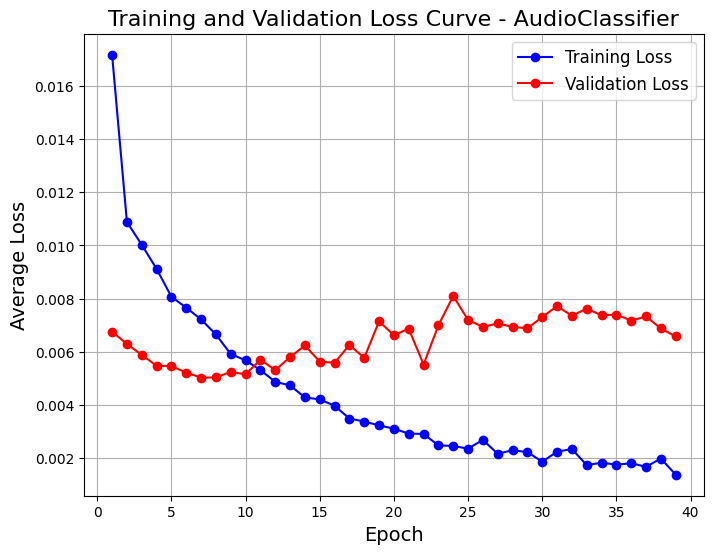

[AudioClassifier] Saved accuracy curve to /kaggle/working/models/audioclassifier_accuracy_curve.png


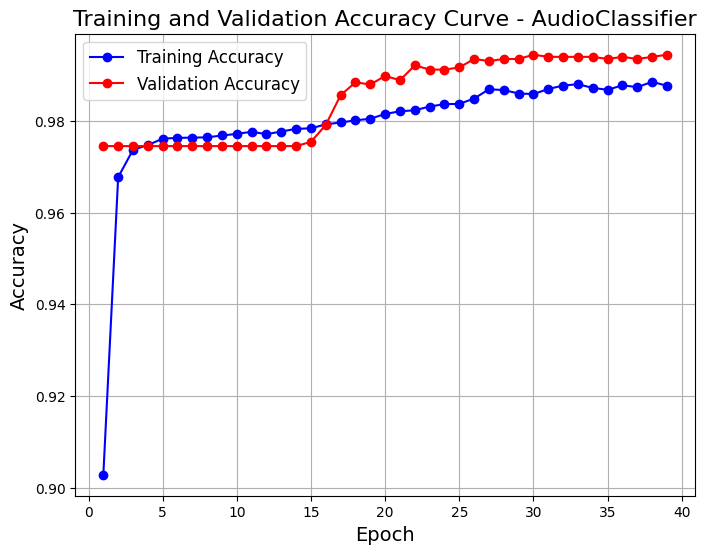

Dataset for test mode: 2157 samples
Class distribution:
label
1    2114
0      43
Name: count, dtype: int64

AudioClassifier Test samples: 0/2157 valid


AudioClassifier Evaluating: 100%|██████████| 270/270 [00:07<00:00, 35.51it/s]


AudioClassifier Final Test Results:
Test Loss: 0.0073 | AUC: 0.9105
Accuracy: 0.9944 | F1: 0.9972
Precision: 0.9944 | Recall: 1.0000
Confusion Matrix:
[[  31   12]
 [   0 2114]]
[AudioClassifier] Saved confusion matrix to /kaggle/working/models/audioclassifier_confusion_matrix.png


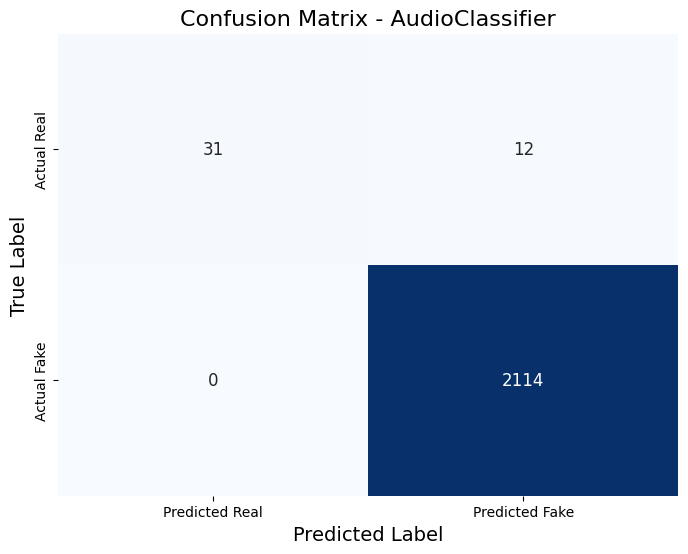

[AudioClassifier] Saved ROC curve to /kaggle/working/models/audioclassifier_roc_curve.png


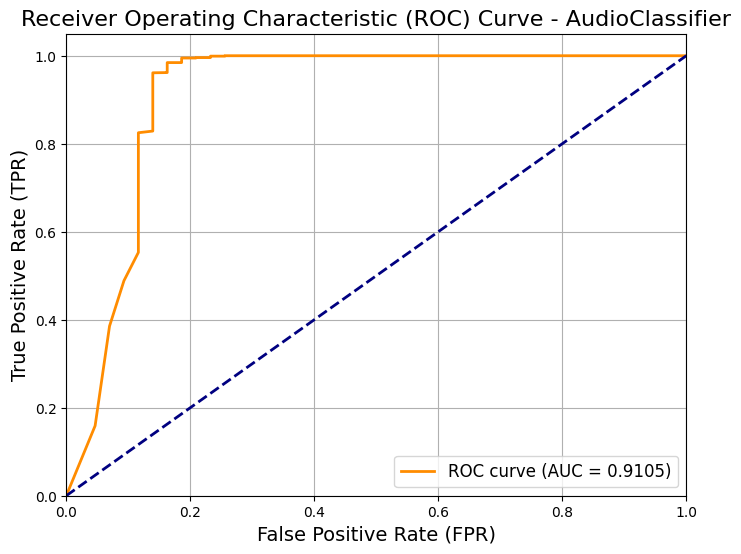


Testing a single video for all models...

Selected video for prediction: /kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-FakeAudio/Asian (South)/women/id00043/00135_fake.mp4

[AudioClassifier] Predicting for video: /kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-FakeAudio/Asian (South)/women/id00043/00135_fake.mp4
[AudioClassifier] Prediction: Fake (Probability of Fake: 99.85%)
[AudioClassifier] True Label: Fake
[AudioClassifier] Correct: True
Main execution completed


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_fscore_support, roc_curve
from tqdm import tqdm
import warnings
import random
import os
warnings.filterwarnings("ignore")

print("Starting main execution...")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class BaseModelTrainer:
    def __init__(self, config, model_class, model_name):
        self.config = config
        self.feature_extractor = FeatureExtractor(config)
        self.model = model_class(config).to(config.DEVICE)
        self.scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer,
            T_max=config.NUM_EPOCHS
        )
        self.criterion = FocalLoss(alpha=0.3, gamma=2.5)
        self.best_score = 0
        self.early_stop_counter = 0
        self.model_name = model_name
        self.best_model_path = config.MODEL_SAVE_PATH / f"best_{model_name.lower()}_model.pth"
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        print(f"{model_name} Trainer initialized")

    def train(self, metadata):
        try:
            print(f"Starting training for {self.model_name}")
            train_dataset = DeepfakeDataset(metadata, self.config, self.feature_extractor, 'train')
            train_loader = DataLoader(
                train_dataset,
                batch_size=self.config.BATCH_SIZE,
                shuffle=True,
                num_workers=self.config.NUM_WORKERS,
                pin_memory=True,
                collate_fn=collate_fn
            )
            
            if len(train_dataset) == 0:
                print(f"No training samples available for {self.model_name}")
                return

            print(f"Train samples: {train_dataset.valid_samples}/{len(train_dataset)} valid")
            if train_dataset.error_log:
                print(f"{self.model_name} Train dataset errors (first 5):")
                for i, (idx, err) in enumerate(train_dataset.error_log[:5]):
                    print(f"Error {i+1}: Item {idx}: {err}")

            for epoch in range(self.config.NUM_EPOCHS):
                self.model.train()
                epoch_loss = 0.0
                valid_samples = 0
                train_preds, train_labels = [], []
                progress_bar = tqdm(train_loader, desc=f"{self.model_name} Epoch {epoch+1}")
                
                for batch in progress_bar:
                    if batch is None:
                        print(f"[{self.model_name}] Skipping empty batch")
                        continue
                        
                    audio = batch['audio'].to(self.config.DEVICE, non_blocking=True)
                    labels = batch['label'].to(self.config.DEVICE, non_blocking=True)
                    
                    self.optimizer.zero_grad(set_to_none=True)
                    try:
                        with torch.cuda.amp.autocast():
                            outputs = self.model(audio)
                            loss = self.criterion(outputs, labels)
                        
                        self.scaler.scale(loss).backward()
                        self.scaler.unscale_(self.optimizer)
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                        self.scaler.step(self.optimizer)
                        self.scaler.update()
                        
                        batch_size = audio.size(0)
                        epoch_loss += loss.item() * batch_size
                        valid_samples += batch_size
                        
                        train_preds.extend(torch.sigmoid(outputs).squeeze().detach().cpu().numpy())
                        train_labels.extend(labels.squeeze().detach().cpu().numpy())
                        
                        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
                        
                    except RuntimeError as e:
                        if "out of memory" in str(e):
                            print(f"[{self.model_name}] WARNING: Out of memory, skipping batch")
                            torch.cuda.empty_cache()
                        else:
                            print(f"[{self.model_name}] Error during training: {e}")
                        continue
                    finally:
                        del audio, labels, outputs
                        torch.cuda.empty_cache()

                if valid_samples > 0:
                    epoch_loss /= valid_samples
                    self.train_losses.append(epoch_loss)
                    train_metrics = self._calculate_metrics(train_preds, train_labels)
                    self.train_accuracies.append(train_metrics['accuracy'])
                    print(f"[{self.model_name}] Epoch {epoch+1}/{self.config.NUM_EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {train_metrics['accuracy']:.4f}")
                else:
                    print(f"[{self.model_name}] No valid samples in epoch {epoch+1}")
                    self.train_losses.append(np.nan)
                    self.train_accuracies.append(np.nan)

                val_loss, val_metrics = self._validate(metadata)
                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_metrics['accuracy'])
                print(f"[{self.model_name}] Val Loss: {val_loss:.4f} | Val AUC: {val_metrics['auc']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1']:.4f}")
                
                if val_metrics['auc'] > self.best_score:
                    self.best_score = val_metrics['auc']
                    self._save_model()
                    self.early_stop_counter = 0
                else:
                    self.early_stop_counter += 1
                    if self.early_stop_counter >= self.config.PATIENCE:
                        print(f"[{self.model_name}] Early stopping after {epoch+1} epochs")
                        break

                self.scheduler.step()
                
        except Exception as e:
            print(f"[{self.model_name}] Error during training: {e}")
            import traceback
            traceback.print_exc()
        finally:
            torch.cuda.empty_cache()

    def evaluate(self, dataloader):
        self.model.eval()
        val_loss = 0.0
        preds, labels = [], []
        valid_batches = 0
        
        with torch.no_grad():
            progress_bar = tqdm(dataloader, desc=f"{self.model_name} Evaluating")
            for batch in progress_bar:
                if batch is None:
                    print(f"[{self.model_name}] Skipping empty batch in evaluation")
                    continue
                    
                audio = batch['audio'].to(self.config.DEVICE, non_blocking=True)
                labels_batch = batch['label'].to(self.config.DEVICE, non_blocking=True)
                
                try:
                    with torch.cuda.amp.autocast():
                        outputs = self.model(audio)
                        loss = self.criterion(outputs, labels_batch)
                    
                    val_loss += loss.item()
                    valid_batches += 1
                    preds.extend(torch.sigmoid(outputs).squeeze().detach().cpu().numpy())
                    labels.extend(labels_batch.squeeze().detach().cpu().numpy())
                    
                except Exception as e:
                    print(f"[{self.model_name}] Error during evaluation: {e}")
                    continue
                finally:
                    del audio, labels_batch
                    if 'outputs' in locals():
                        del outputs
                    torch.cuda.empty_cache()
        
        if valid_batches == 0 or len(preds) == 0:
            print(f"[{self.model_name}] No valid batches in evaluation")
            return 0.0, {
                'auc': 0.0, 'accuracy': 0.0, 'f1': 0.0,
                'confusion_matrix': np.zeros((2,2), dtype=int),
                'precision': 0.0, 'recall': 0.0,
                'roc_curve': ([0, 1], [0, 1], [0, 1])
            }
            
        val_loss /= valid_batches
        metrics = self._calculate_metrics(preds, labels)
        np.save(self.config.MODEL_SAVE_PATH / f"{self.model_name.lower()}_test_preds.npy", np.array(preds))
        np.save(self.config.MODEL_SAVE_PATH / f"{self.model_name.lower()}_test_labels.npy", np.array(labels))
        return val_loss, metrics

    def _validate(self, metadata):
        val_dataset = DeepfakeDataset(metadata, self.config, self.feature_extractor, 'val')
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=False,
            num_workers=self.config.NUM_WORKERS,
            pin_memory=True,
            collate_fn=collate_fn
        )
        return self.evaluate(val_loader)

    def _calculate_metrics(self, preds, labels):
        preds = np.array(preds)
        labels = np.array(labels)
        binary_preds = (preds > 0.5).astype(int)
        
        try:
            auc = roc_auc_score(labels, preds)
            fpr, tpr, thresholds = roc_curve(labels, preds)
        except Exception as e:
            print(f"[{self.model_name}] Error calculating ROC: {e}")
            auc = 0.0
            fpr, tpr, thresholds = [0, 1], [0, 1], [0, 1]
            
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, binary_preds, average='binary', zero_division=0
        )
        
        return {
            'auc': auc,
            'accuracy': accuracy_score(labels, binary_preds),
            'f1': f1,
            'confusion_matrix': confusion_matrix(labels, binary_preds).astype(int),
            'precision': precision,
            'recall': recall,
            'roc_curve': (fpr, tpr, thresholds)
        }

    def _save_model(self):
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_score': self.best_score,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accuracies': self.train_accuracies,
            'val_accuracies': self.val_accuracies,
            'config': {k: v for k, v in vars(self.config).items() 
                      if not callable(v) and not k.startswith('__')}
        }, self.best_model_path)
        print(f"{self.model_name} saved with best AUC: {self.best_score:.4f}")

    def plot_training_loss(self):
        if not self.train_losses or all(np.isnan(self.train_losses)):
            print(f"[{self.model_name}] No training loss data available, skipping loss plot")
            return
        try:
            plt.figure(figsize=(8, 6))
            plt.plot(range(1, len(self.train_losses) + 1), self.train_losses, marker='o', color='blue', label='Training Loss')
            if self.val_losses and not all(np.isnan(self.val_losses)):
                plt.plot(range(1, len(self.val_losses) + 1), self.val_losses, marker='o', color='red', label='Validation Loss')
            plt.xlabel('Epoch', fontsize=14)
            plt.ylabel('Average Loss', fontsize=14)
            plt.title(f'Training and Validation Loss Curve - {self.model_name}', fontsize=16)
            plt.legend(fontsize=12)
            plt.grid(True)
            save_path = self.config.MODEL_SAVE_PATH / f"{self.model_name.lower()}_loss_curve.png"
            os.makedirs(self.config.MODEL_SAVE_PATH, exist_ok=True)
            plt.savefig(save_path)
            print(f"[{self.model_name}] Saved loss curve to {save_path}")
            plt.show()
            plt.close()
        except Exception as e:
            print(f"[{self.model_name}] Error saving loss curve: {e}")

    def plot_training_accuracy(self):
        if not self.train_accuracies or all(np.isnan(self.train_accuracies)):
            print(f"[{self.model_name}] No training accuracy data available, skipping accuracy plot")
            return
        try:
            plt.figure(figsize=(8, 6))
            plt.plot(range(1, len(self.train_accuracies) + 1), self.train_accuracies, marker='o', color='blue', label='Training Accuracy')
            if self.val_accuracies and not all(np.isnan(self.val_accuracies)):
                plt.plot(range(1, len(self.val_accuracies) + 1), self.val_accuracies, marker='o', color='red', label='Validation Accuracy')
            plt.xlabel('Epoch', fontsize=14)
            plt.ylabel('Accuracy', fontsize=14)
            plt.title(f'Training and Validation Accuracy Curve - {self.model_name}', fontsize=16)
            plt.legend(fontsize=12)
            plt.grid(True)
            save_path = self.config.MODEL_SAVE_PATH / f"{self.model_name.lower()}_accuracy_curve.png"
            os.makedirs(self.config.MODEL_SAVE_PATH, exist_ok=True)
            plt.savefig(save_path)
            print(f"[{self.model_name}] Saved accuracy curve to {save_path}")
            plt.show()
            plt.close()
        except Exception as e:
            print(f"[{self.model_name}] Error saving accuracy curve: {e}")

def train_and_evaluate_model(config, metadata_sampled, model_class, model_name):
    print(f"\n=== Training and Evaluating {model_name} ===")
    
    trainer = BaseModelTrainer(config, model_class, model_name)
    
    if trainer.best_model_path.exists():
        try:
            checkpoint = torch.load(trainer.best_model_path, weights_only=False)
            trainer.model.load_state_dict(checkpoint['model_state_dict'])
            trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            trainer.best_score = checkpoint.get('best_score', 0)
            trainer.train_losses = checkpoint.get('train_losses', [])
            trainer.val_losses = checkpoint.get('val_losses', [])
            trainer.train_accuracies = checkpoint.get('train_accuracies', [])
            trainer.val_accuracies = checkpoint.get('val_accuracies', [])
            print(f"Loaded {model_name} with best AUC: {trainer.best_score:.4f}")
        except Exception as e:
            print(f"[{model_name}] Error loading model: {e}")
    
    try:
        trainer.train(metadata_sampled)
    except KeyboardInterrupt:
        print(f"[{model_name}] Training interrupted. Saving current model state...")
        trainer._save_model()
    except Exception as e:
        print(f"[{model_name}] Error during training: {e}")
    
    trainer.plot_training_loss()
    trainer.plot_training_accuracy()
    
    test_loss = 0.0
    test_metrics = {
        'auc': 0.0, 'accuracy': 0.0, 'f1': 0.0,
        'confusion_matrix': np.zeros((2,2), dtype=int),
        'precision': 0.0, 'recall': 0.0,
        'roc_curve': ([0, 1], [0, 1], [0, 1])
    }
    
    try:
        test_dataset = DeepfakeDataset(metadata_sampled, config, trainer.feature_extractor, 'test')
        test_loader = DataLoader(
            test_dataset,
            batch_size=config.BATCH_SIZE,
            shuffle=False,
            num_workers=config.NUM_WORKERS,
            pin_memory=True,
            collate_fn=collate_fn
        )
        
        print(f"\n{model_name} Test samples: {test_dataset.valid_samples}/{len(test_dataset)} valid")
        if test_dataset.error_log:
            print(f"{model_name} Test dataset errors (first 5):")
            for i, (idx, err) in enumerate(test_dataset.error_log[:5]):
                print(f"Error {i+1}: Item {idx}: {err}")
        
        test_loss, test_metrics = trainer.evaluate(test_loader)
    except Exception as e:
        print(f"[{model_name}] Error during evaluation: {e}")
    
    print(f"\n{model_name} Final Test Results:")
    print(f"Test Loss: {test_loss:.4f} | AUC: {test_metrics['auc']:.4f}")
    print(f"Accuracy: {test_metrics['accuracy']:.4f} | F1: {test_metrics['f1']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f} | Recall: {test_metrics['recall']:.4f}")
    print(f"Confusion Matrix:\n{test_metrics['confusion_matrix']}")
    
    try:
        plt.figure(figsize=(8, 6))
        sns.heatmap(test_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Predicted Real', 'Predicted Fake'],
                    yticklabels=['Actual Real', 'Actual Fake'],
                    annot_kws={"size": 12})
        plt.xlabel('Predicted Label', fontsize=14)
        plt.ylabel('True Label', fontsize=14)
        plt.title(f'Confusion Matrix - {model_name}', fontsize=16)
        save_path = config.MODEL_SAVE_PATH / f"{model_name.lower()}_confusion_matrix.png"
        os.makedirs(config.MODEL_SAVE_PATH, exist_ok=True)
        plt.savefig(save_path)
        print(f"[{model_name}] Saved confusion matrix to {save_path}")
        plt.show()
        plt.close()
    except Exception as e:
        print(f"[{model_name}] Error saving confusion matrix: {e}")
    
    try:
        fpr, tpr, _ = test_metrics['roc_curve']
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_metrics["auc"]:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (FPR)', fontsize=14)
        plt.ylabel('True Positive Rate (TPR)', fontsize=14)
        plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}', fontsize=16)
        plt.legend(loc="lower right", fontsize=12)
        plt.grid(True)
        save_path = config.MODEL_SAVE_PATH / f"{model_name.lower()}_roc_curve.png"
        os.makedirs(config.MODEL_SAVE_PATH, exist_ok=True)
        plt.savefig(save_path)
        print(f"[{model_name}] Saved ROC curve to {save_path}")
        plt.show()
        plt.close()
    except Exception as e:
        print(f"[{model_name}] Error saving ROC curve: {e}")
    
    return test_metrics, trainer

def predict_single_video(video_path, config, trainer, model_name):
    print(f"\n[{model_name}] Predicting for video: {video_path}")
    try:
        feature_extractor = trainer.feature_extractor
        audio_features = feature_extractor.extract_audio_features(video_path)
        if audio_features is None:
            print(f"[{model_name}] Failed to extract audio features for {video_path}")
            return None, None, None
        
        mfcc = audio_features['mfcc']
        if np.isnan(mfcc).any():
            mfcc = np.nan_to_num(mfcc)
        std_val = mfcc.std(axis=1, keepdims=True)
        if not np.all(std_val == 0):
            mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (std_val + 1e-8)
        audio_feat = DeepfakeDataset._pad_or_truncate(mfcc.T, 50)
        
        audio_tensor = torch.FloatTensor(audio_feat).unsqueeze(0).to(config.DEVICE)
        
        trainer.model.eval()
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                output = trainer.model(audio_tensor)
                prob = torch.sigmoid(output).item()
                pred = 1 if prob > 0.5 else 0
        
        true_label = None
        category_map = {
            'RealVideo-RealAudio': 0,
            'RealVideo-FakeAudio': 1,
            'FakeVideo-RealAudio': 0,
            'FakeVideo-FakeAudio': 1
        }
        for category, label in category_map.items():
            if category in str(video_path):
                true_label = label
                break
        
        prob_display = prob if pred == 1 else (1 - prob)
        label_display = 'Fake' if pred == 1 else 'Real'
        print(f"[{model_name}] Prediction: {label_display} (Probability of {label_display}: {prob_display * 100:.2f}%)")
        if true_label is not None:
            print(f"[{model_name}] True Label: {'Fake' if true_label == 1 else 'Real'}")
            print(f"[{model_name}] Correct: {pred == true_label}")
        
        return pred, prob, true_label
    
    except Exception as e:
        print(f"[{model_name}] Error predicting for {video_path}: {e}")
        return None, None, None

if __name__ == "__main__":
    try:
        set_seed(42)
        config = Config()
        metadata = pd.read_csv(config.METADATA_FILE)
        metadata = metadata.loc[:, ~metadata.columns.str.contains('^Unnamed')]
        
        print("Available columns in meta_data.csv:", list(metadata.columns))
        print("First 5 rows of metadata:\n", metadata[['path', 'category', 'race', 'gender', 'source']].head().to_string())
        
        required_cols = ['path', 'category', 'race', 'gender', 'source']
        for col in required_cols:
            if col not in metadata.columns:
                raise ValueError(f"Missing required column: {col}")
        
        print("\nValidating first 5 paths:")
        valid_paths = 0
        for idx, row in metadata.head().iterrows():
            category_map = {
                'A': 'RealVideo-RealAudio',
                'B': 'RealVideo-FakeAudio',
                'C': 'FakeVideo-RealAudio',
                'D': 'FakeVideo-FakeAudio'
            }
            root_dir = category_map.get(row['category'], 'FakeVideo-FakeAudio')
            race = row.get('race', 'Unknown')
            gender = row.get('gender', 'men').lower()
            source_id = row.get('source', row.get('target1', 'id00000'))
            dir_path = config.DATASET_PATH / root_dir / race / gender / source_id
            video_path = config.DATASET_PATH / row['path']
            if video_path.suffix == '.mp4' and video_path.exists():
                print(f"Valid path: {video_path}")
                valid_paths += 1
            else:
                video_files = list(dir_path.glob("*.mp4"))
                print(f"Directory {dir_path}: {len(video_files)} .mp4 files found")
                if video_files:
                    valid_paths += 1
        print(f"Path validation: {valid_paths}/5 paths valid")
        
        split_file = config.PROCESSED_DATA_PATH / "metadata_split.csv"
        if not split_file.exists():
            a_data = metadata[metadata['category'] == 'A'].sample(n=500, random_state=42, replace=True)
            b_data = metadata[metadata['category'] == 'B'].sample(n=500, random_state=42, replace=True)
            c_data = metadata[metadata['category'] == 'C'].sample(n=9709, random_state=42, replace=True)
            d_data = metadata[metadata['category'] == 'D'].sample(n=10857, random_state=42, replace=True)
            metadata_sampled = pd.concat([a_data, b_data, c_data, d_data]).sample(frac=1, random_state=42).reset_index(drop=True)
        
            n = len(metadata_sampled)
            train_end = int(0.8 * n)
            val_end = int(0.9 * n)
            metadata_sampled['split'] = ['train'] * train_end + ['val'] * (val_end - train_end) + ['test'] * (n - val_end)
            metadata_sampled = metadata_sampled.sample(frac=1, random_state=42).reset_index(drop=True)
        
            metadata_sampled.to_csv(split_file, index=False)
            print(f"Saved metadata split to {split_file}")
        else:
            metadata_sampled = pd.read_csv(split_file)
            print(f"Loaded metadata split from {split_file}")

        print(f"\nDataset size: {len(metadata_sampled)}")
        print(f"Class distribution:\n{metadata_sampled['category'].value_counts()}")
        print(f"Split distribution:\n{metadata_sampled['split'].value_counts()}")
        
        models = [(AudioClassifier, "AudioClassifier")]
        
        print("\nModel Parameter Counts:")
        for model_class, model_name in models:
            model = model_class(config)
            total_params = sum(p.numel() for p in model.parameters())
            print(f"{model_name}: {total_params:,} total parameters")
            del model
            torch.cuda.empty_cache()
        
        trainers = []
        for model_class, model_name in models:
            try:
                test_metrics, trainer = train_and_evaluate_model(config, metadata_sampled, model_class, model_name)
                trainers.append((trainer, model_name))
            except Exception as e:
                print(f"[{model_name}] Error during training/evaluation: {e}")
                import traceback
                traceback.print_exc()
                continue
            finally:
                torch.cuda.empty_cache()
        
        print("\nTesting a single video for all models...")
        test_metadata = metadata_sampled[metadata_sampled['split'] == 'test'].reset_index(drop=True)
        if not test_metadata.empty:
            video_path = Path("/kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-FakeAudio/Asian (South)/women/id00043/00135_fake.mp4")
            if not video_path.exists():
                print(f"Video file not found: {video_path}, falling back to first test video")
                row = test_metadata.iloc[0]
                category_map = {
                    'A': 'RealVideo-RealAudio',
                    'B': 'RealVideo-FakeAudio',
                    'C': 'FakeVideo-RealAudio',
                    'D': 'FakeVideo-FakeAudio'
                }
                root_dir = category_map.get(row['category'], 'FakeVideo-FakeAudio')
                race = row.get('race', 'Unknown')
                gender = row.get('gender', 'men').lower()
                source_id = row.get('source', row.get('target1', 'id00000'))
                dir_path = config.DATASET_PATH / root_dir / race / gender / source_id
                video_path = config.DATASET_PATH / row['path']
                if video_path.suffix == '.mp4' and video_path.exists():
                    print(f"Valid path: {video_path}")
                else:
                    video_files = list(dir_path.glob("*.mp4"))
                    if video_files:
                        video_path = video_files[0]
                        print(f"Selected video file: {video_path}")
            
            if video_path.exists():
                print(f"\nSelected video for prediction: {video_path}")
                for trainer, model_name in trainers:
                    try:
                        if trainer.best_model_path.exists():
                            checkpoint = torch.load(trainer.best_model_path, weights_only=False)
                            trainer.model.load_state_dict(checkpoint['model_state_dict'])
                            predict_single_video(video_path, config, trainer, model_name)
                        else:
                            print(f"[{model_name}] No trained model found, skipping prediction")
                    except Exception as e:
                        print(f"[{model_name}] Error during single video prediction: {e}")
            else:
                print(f"Video file not found: {video_path}")
        else:
            print("No test videos available for single video prediction")
    
    except Exception as e:
        print(f"Error during execution: {e}")
        import traceback
        traceback.print_exc()
    
    print("Main execution completed")